In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.DataFrame(np.random.randint(1,100,(20,5)),columns=["A","B","C","D","E"])
df

,A,B,C,D,E
0,14,34,18,35,66
1,79,95,58,6,72
2,11,86,31,65,75
3,47,71,50,56,10
4,22,79,40,11,83
5,40,41,55,36,16
6,94,79,9,71,81
7,57,93,17,60,21
8,16,19,8,88,20
9,11,90,28,24,46


In [4]:
df.apply(sum)

A     931
B    1196
C     852
D     904
E     948
dtype: int64

In [5]:
df.apply("mean")

A    46.55
B    59.80
C    42.60
D    45.20
E    47.40
dtype: float64

In [6]:
df.apply(["mean",sum])

,A,B,C,D,E
mean,46.55,59.8,42.6,45.2,47.4
sum,931.00,1196.0,852.0,904.0,948.0


In [7]:
df.apply(sum,axis=1)

0     167
1     310
2     268
3     234
4     235
5     188
6     334
7     248
8     151
9     199
10    213
11    249
12    331
13    162
14    312
15    331
16    222
17    285
18    136
19    256
dtype: int64

In [8]:
df.apply(lambda x:x["A"]+x["B"]+x["C"],axis=1)

0      66
1     232
2     128
3     168
4     141
5     136
6     182
7     167
8      43
9     129
10    138
11    142
12    272
13     93
14    166
15    166
16    198
17    157
18     99
19    156
dtype: int32

In [10]:
df["Total"]=df.apply(sum,axis=1)

In [11]:
df

,A,B,C,D,E,Total
0,14,34,18,35,66,334
1,79,95,58,6,72,620
2,11,86,31,65,75,536
3,47,71,50,56,10,468
4,22,79,40,11,83,470
5,40,41,55,36,16,376
6,94,79,9,71,81,668
7,57,93,17,60,21,496
8,16,19,8,88,20,302
9,11,90,28,24,46,398


In [13]:
def grade(x):
    if x>600:
        return "A+"
    if x>500:
        return "A"
    if x>400:
        return "B"
    return "F"

In [14]:
df["Grade"]=df["Total"].apply(grade)
df

,A,B,C,D,E,Total,Grade
0,14,34,18,35,66,334,F
1,79,95,58,6,72,620,A+
2,11,86,31,65,75,536,A
3,47,71,50,56,10,468,B
4,22,79,40,11,83,470,B
5,40,41,55,36,16,376,F
6,94,79,9,71,81,668,A+
7,57,93,17,60,21,496,B
8,16,19,8,88,20,302,F
9,11,90,28,24,46,398,F


In [23]:
def mark(x):
    if x["A"]<35 or x["B"]<35 or x["C"]<35 or x["D"]<35 or x["E"]<35:
        return "Fail"
    return "Pass"

In [22]:
df.apply(mark,axis=1)

0     Fail
1     Fail
2     Fail
3     Fail
4     Fail
5     Fail
6     Fail
7     Fail
8     Fail
9     Fail
10    Fail
11    Fail
12    Fail
13    Fail
14    Fail
15    Fail
16    Fail
17    Fail
18    Fail
19    Fail
dtype: object

In [24]:
df = pd.read_csv("social_media_engagement.csv")
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [25]:
def decide(x):
    if x>3000:
        return "Good"

In [26]:
df["likes"].apply(decide)

0     None
1     Good
2     Good
3     None
4     Good
      ... 
95    None
96    None
97    None
98    Good
99    Good
Name: likes, Length: 100, dtype: object

In [37]:
df["risk"]=df.apply(deci,axis=1)

In [38]:
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Medium
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,High risk
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive,Medium
...,...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive,Vandho nai
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral,Vandho nai
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive,Vandho nai
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive,Medium


In [36]:
def deci(x):
    if x["likes"]>500 and x["comments"]<100:
        return "High risk"
    elif x["likes"]>2000:
        return "Medium"
    elif x["shares"]>1000:
        return "Low"
    else:
        return "Vandho nai"

In [40]:
df.groupby("platform").head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Medium
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,High risk
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive,Medium
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral,Vandho nai
6,7,Instagram,image,2/26/2023 11:45,1982,30,906,Sunday,positive,High risk
7,8,Instagram,text,10/28/2023 19:30,1274,45,216,Saturday,neutral,High risk
8,9,Facebook,video,5/2/2023 6:15,317,249,221,Tuesday,neutral,Vandho nai
9,10,Twitter,carousel,5/11/2023 11:00,1878,225,438,Thursday,neutral,Vandho nai


In [41]:
df.platform.unique()

array(['Facebook', 'Instagram', 'Twitter'], dtype=object)

In [42]:
for name,data in df.groupby("platform"):
    print(name,"\n",data)

Facebook 
     post_id  platform post_type         post_time  likes  comments  shares  \
0         1  Facebook     image   8/17/2023 14:45   2121       474     628   
1         2  Facebook  carousel    5/14/2023 0:45   3660       432     694   
8         9  Facebook     video     5/2/2023 6:15    317       249     221   
12       13  Facebook  carousel  11/11/2023 15:45     45        78     375   
14       15  Facebook  carousel    1/9/2023 20:00    889       314     262   
19       20  Facebook     image    2/2/2023 16:00    455        86      79   
25       26  Facebook  carousel    10/5/2023 6:30   1992        70     515   
27       28  Facebook      poll     3/1/2023 8:00   2083       500     388   
28       29  Facebook     image    1/7/2023 10:30    548       153     731   
29       30  Facebook  carousel     2/3/2023 0:30   4594       216     739   
30       31  Facebook      poll   9/10/2023 13:45   4795       449     978   
35       36  Facebook     video    4/8/2023 19:15   5

In [43]:
df.groupby('platform').sample()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,risk
47,48,Facebook,video,3/22/2023 3:15,5000,232,16,Wednesday,negative,Medium
43,44,Instagram,text,7/6/2023 8:00,3259,50,177,Thursday,negative,High risk
15,16,Twitter,image,2/10/2023 13:00,2348,154,18,Friday,neutral,Medium


In [44]:
df.groupby("platform").groups

{'Facebook': [0, 1, 8, 12, 14, 19, 25, 27, 28, 29, 30, 35, 36, 38, 46, 47, 57, 61, 65, 66, 69, 71, 72, 74, 79, 80, 83, 84, 87, 90, 91, 93], 'Instagram': [2, 5, 6, 7, 16, 23, 26, 31, 34, 39, 41, 43, 45, 49, 53, 55, 56, 59, 60, 63, 64, 67, 70, 73, 75, 77, 78, 81, 82, 86, 89, 92, 94, 95, 98, 99], 'Twitter': [3, 4, 9, 10, 11, 13, 15, 17, 18, 20, 21, 22, 24, 32, 33, 37, 40, 42, 44, 48, 50, 51, 52, 54, 58, 62, 68, 76, 85, 88, 96, 97]}

In [45]:
df.groupby("platform").nunique()

,post_id,post_type,post_time,likes,comments,shares,post_day,sentiment_score,risk
platform,,,,,,,,,
Facebook,32,5,32,29,28,32,7,3,3
Instagram,36,5,36,33,34,36,7,3,3
Twitter,32,5,32,32,31,31,7,3,3


In [46]:
df.groupby("platform")["likes"].sum()

platform
Facebook      86392
Instagram    107994
Twitter       43795
Name: likes, dtype: int64

In [47]:
df.groupby("platform")["comments"].sum()

platform
Facebook     7965
Instagram    8368
Twitter      3933
Name: comments, dtype: int64

In [48]:
df.groupby("platform",as_index=False)["likes"].sum()

,platform,likes
0,Facebook,86392
1,Instagram,107994
2,Twitter,43795


In [50]:
df.groupby("platform")[["likes","comments","shares"]].mean()

,likes,comments,shares
platform,,,
Facebook,2699.750000,248.906250,474.375000
Instagram,2999.833333,232.444444,525.166667
Twitter,1368.593750,122.906250,233.718750


In [51]:
df.groupby("platform",as_index=False).agg({"likes":[sum,"mean"],"comments":"mean"})

C:\Users\Neel\AppData\Local\Temp\ipykernel_10612\4127958159.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.groupby("platform",as_index=False).agg({"likes":[sum,"mean"],"comments":"mean"})


platform   likes                 comments
                 sum         mean        mean
0   Facebook   86392  2699.750000  248.906250
1  Instagram  107994  2999.833333  232.444444
2    Twitter   43795  1368.593750  122.906250

In [52]:
df.groupby("platform").nth(0)

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,High risk


In [53]:
df=pd.read_csv("movies.csv")
df

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [54]:
df.groupby('genres')['imdb_rating'].mean().sort_values()

genres
Biography|History          0.0
Drama|Short                0.0
Comedy|Family|Sci-Fi       2.4
Action|Crime|Romance       2.4
Action|Fantasy|Sci-Fi      2.6
                          ... 
Adventure|Drama|Musical    8.1
Drama|Fantasy|Horror       8.2
Drama|Short|Thriller       8.2
Documentary|War            8.3
Documentary|Sport          8.6
Name: imdb_rating, Length: 205, dtype: float64

In [55]:
df.groupby('genres')['imdb_rating'].mean().sort_values(ascending=False).head()

genres
Documentary|Sport          8.6
Documentary|War            8.3
Drama|Short|Thriller       8.2
Drama|Fantasy|Horror       8.2
Adventure|Drama|Musical    8.1
Name: imdb_rating, dtype: float64

In [56]:
df.groupby('genres')['imdb_rating'].max()

genres
Action                        7.4
Action|Adventure              5.3
Action|Adventure|Animation    6.8
Action|Adventure|Comedy       7.2
Action|Adventure|Crime        3.5
                             ... 
Romance|Thriller              5.7
Sci-Fi                        5.8
Sport                         5.3
Thriller                      7.9
War                           4.1
Name: imdb_rating, Length: 205, dtype: float64

In [57]:
df = pd.read_csv("social_media_engagement.csv")
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [58]:
import seaborn as sns

In [59]:
df.corr(numeric_only=True)

,post_id,likes,comments,shares
post_id,1.000000,0.139260,0.135507,0.071436
likes,0.139260,1.000000,0.295240,0.244302
comments,0.135507,0.295240,1.000000,0.254583
shares,0.071436,0.244302,0.254583,1.000000


<Axes: >

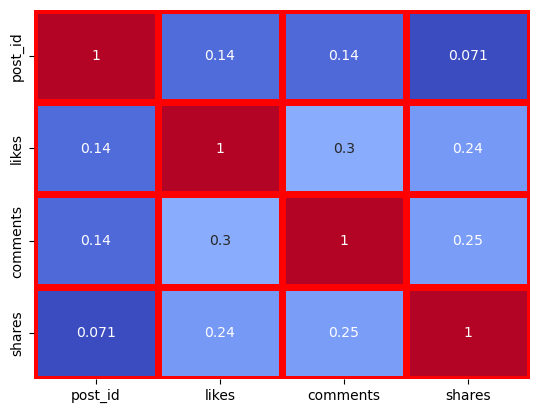

In [61]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linecolor="red",linewidths=5,annot=True,cbar=False)

<Axes: >

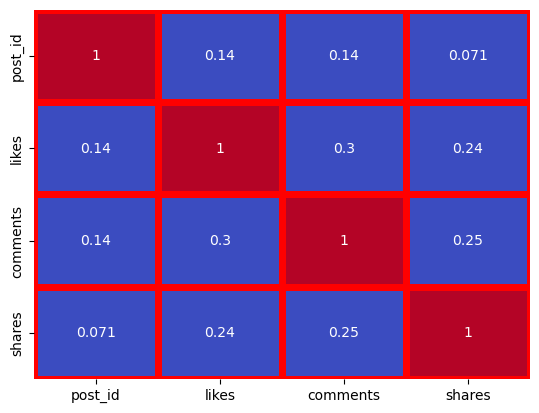

In [64]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linecolor="red",linewidths=5,annot=True,cbar=False,vmin=0.3)

<Axes: >

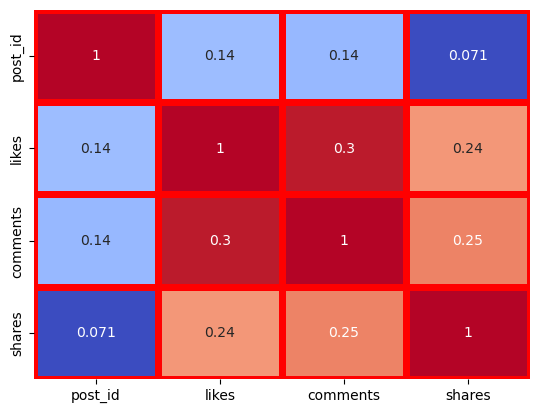

In [65]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linecolor="red",linewidths=5,annot=True,cbar=False,vmax=0.3)

<Axes: xlabel='likes'>

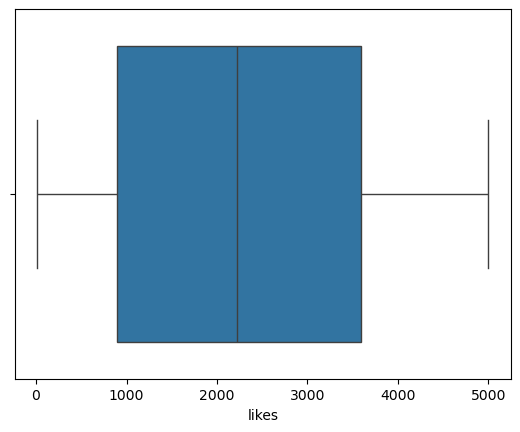

In [66]:
sns.boxplot(data=df,x="likes")

<Axes: xlabel='likes'>

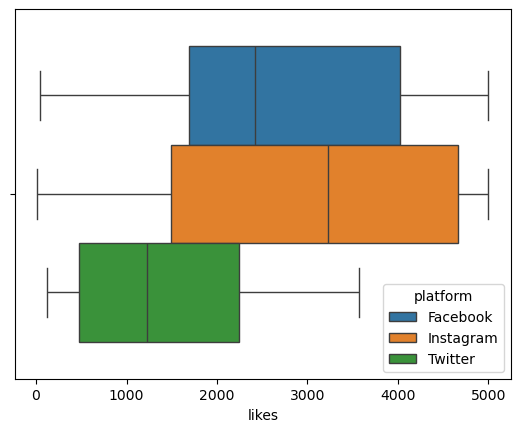

In [68]:
sns.boxplot(data=df,x='likes',hue='platform')

<Axes: xlabel='likes', ylabel='comments'>

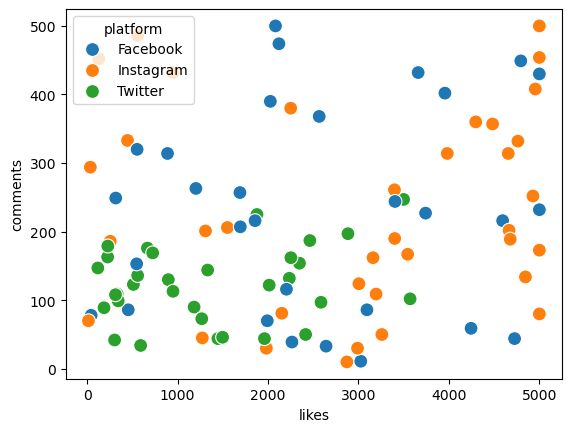

In [70]:
sns.scatterplot(data=df,x='likes',y='comments',hue="platform",s=100)

In [74]:
import plotly